# ndlar_flow in 45 minutes — Workshop2026 version

Read a **flow file** (`.FLOW.hdf5`), and match simulated hits to MC truth.

| Part | Goal |
|---|---|
| 1 | open a file (two readers) |
| 2 | `data` / `ref` / `ref_region`, units |
| 3 | charge hits: three ways to read them, event display |
| 4 | MC truth: interactions / trajectories / segments |
| 5 | **backtracking: hit → segment → particle** |
| 6 | **example analysis: dE/dx from pixel hits** |
| 7 | producing a flow file yourself |

Run top to bottom — cells reuse earlier variables.

## 1 — Setup

In [2]:
%%capture
!pip install jupyter matplotlib h5py numpy legacy-cgi scienceplots
!cd ../.. && git clone https://github.com/DUNE/h5flow && pip install -e ./h5flow
!cd .. && pip install -e .

### WARNING: Restart kernel if you have to for the next step, sometimes packages wont be recognized immediately! ###

In [2]:
import sys
from pathlib import Path
import numpy as np
import h5py
import matplotlib.pyplot as plt
import h5flow
from h5flow.data import dereference

try:
    import scienceplots
    plt.style.use(['science', 'no-latex'])
except Exception:
    pass
plt.rcParams.update({"figure.dpi": 130, "font.size": 9.5,
                     "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.5})

SEQ_CMAP   = "viridis"                    # magnitudes (Q, E, t)
ONE_SERIES = "#3e7fcd"                    # single-series histograms
CATEGORICAL = ["#3b6fb0", "#e06c15", "#00a06b", "#9457c9", "#c23a5e"]   # species
NEUTRAL     = "#8a8f98"                   # "other" / unmatched

print(f"numpy {np.__version__} | h5py {h5py.__version__} | "
      f"h5flow {getattr(h5flow, '__version__', 'unknown')}")

numpy 2.4.6 | h5py 3.16.0 | h5flow unknown


**Get a file:** MiniRun productions on the [NERSC portal](https://portal.nersc.gov/project/dune/data/2x2/simulation/),
or your own `larnd-sim` output run through the flow (Part 6).
Parts 4–5 need **simulation** (`mc_truth`); detector data stops at Part 3.

Two readers, two jobs:
* `h5py.File` — whole datasets as structured numpy arrays. File-wide distributions.
* `H5FlowDataManager` — follows the **references**: `mgr["charge/events", "charge/calib_final_hits", 7]`. Per-event reading.

In [3]:
MC = True   

if MC:
    FLOW_FILE = Path('/pscratch/sd/d/dunepro/mkramer/output/CentiRun7_1E20_RHC/run-ndlar-flow/CentiRun7_1E20_RHC.flow/FLOW/0000000/CentiRun7_1E20_RHC.flow.0000137.FLOW.hdf5')
else:
    FLOW_FILE = Path('/pscratch/sd/d/dunepro/mkramer/output/Reflow_2x2_Run2_v0p2_dtg_nominal/flow/cosmics_bin14/mpd_run_run2data_rctl_949_p8_v0p2.FLOW.hdf5')

f_h5      = h5py.File(FLOW_FILE, "r")
f_manager = h5flow.data.H5FlowDataManager(str(FLOW_FILE), "r", mpi=False)

HAS_TRUTH = "mc_truth" in f_h5
HAS_LIGHT = "light" in f_h5

print(FLOW_FILE.name)
print("groups   :", list(f_h5.keys()))
print(f"mc_truth : {HAS_TRUTH}    light : {HAS_LIGHT}")

CentiRun7_1E20_RHC.flow.0000137.FLOW.hdf5
groups   : ['charge', 'combined', 'geometry_info', 'lar_info', 'light', 'mc_truth', 'run_info']
mc_truth : True    light : True


## 2 — File layout

`charge/` pixel readout - `light/` SiPMs - `combined/` cross-system (`t0`) -
`mc_truth/` simulation only - `geometry_info/`, `lar_info/`, `run_info/` metadata.

**The one structural idea.** Every dataset is a group:

```
charge/calib_final_hits/
├── data                       one row per hit
└── ref/charge/calib_prompt_hits/
    ├── ref                    (N,2) index pairs: (parent row, child row)
    └── ref_region             per parent row: which slice of `ref` to read
```

`H5FlowDataManager[...]` just walks that, in either direction. By hand:

```python
dereference(7, ref=..., region=..., data=...)
```

In [4]:
for group_name in f_h5.keys():
    print(f"{group_name}/ :", ", ".join(f_h5[group_name].keys()))

charge/ : calib_final_hits, calib_prompt_hits, events, ext_trigs, packets, packets_corr_ts, raw_events, raw_hits
combined/ : t0
geometry_info/ : anode_drift_coordinate, det_bounds, det_id, det_rel_pos, det_type, disabled_channels, disabled_chips, drift_dir, pixel_coordinates_2D, sipm_abs_pos, sipm_rel_pos, tile_id
lar_info/ : 
light/ : events, flash, sipm_hits, sum_hits, sum_tpc_hits, t_ns, wvfm
mc_truth/ : calib_final_hit_backtrack, calib_prompt_hit_backtrack, interactions, light_module0, light_module1, light_module2, light_module3, packet_fraction, segments, stack, trajectories
run_info/ : 


In [5]:
# the file's relationship map: which dereference chains are possible
refs = []
def _collect(name, obj):
    if isinstance(obj, h5py.Dataset) and name.endswith("/ref"):
        parent, child = name.split("/ref/", 1)
        refs.append((parent, child[:-len("/ref")], obj.shape[0]))
f_h5.visititems(_collect)

print(f"{'parent':34s} -> {'child':38s} {'pairs':>9s}")
for parent, child, n_pairs in sorted(refs):
    print(f"{parent:34s} -> {child:38s} {n_pairs:>9,}")

parent                             -> child                                      pairs
charge/calib_final_hits            -> mc_truth/calib_final_hit_backtrack       118,724
charge/calib_prompt_hits           -> charge/calib_final_hits                  118,724
charge/calib_prompt_hits           -> charge/packets                           152,651
charge/calib_prompt_hits           -> mc_truth/calib_prompt_hit_backtrack      152,651
charge/events                      -> charge/calib_final_hits                  118,724
charge/events                      -> charge/calib_prompt_hits                 152,651
charge/events                      -> charge/ext_trigs                             188
charge/events                      -> charge/raw_hits                          152,651
charge/events                      -> combined/t0                                  188
charge/events                      -> light/events                                 188
charge/ext_trigs                   -> light

### WARNING: There is a bug for the prompt->final matching present in files produced before September 14th, 2026 ###

## Hit reconstruction in flow ##
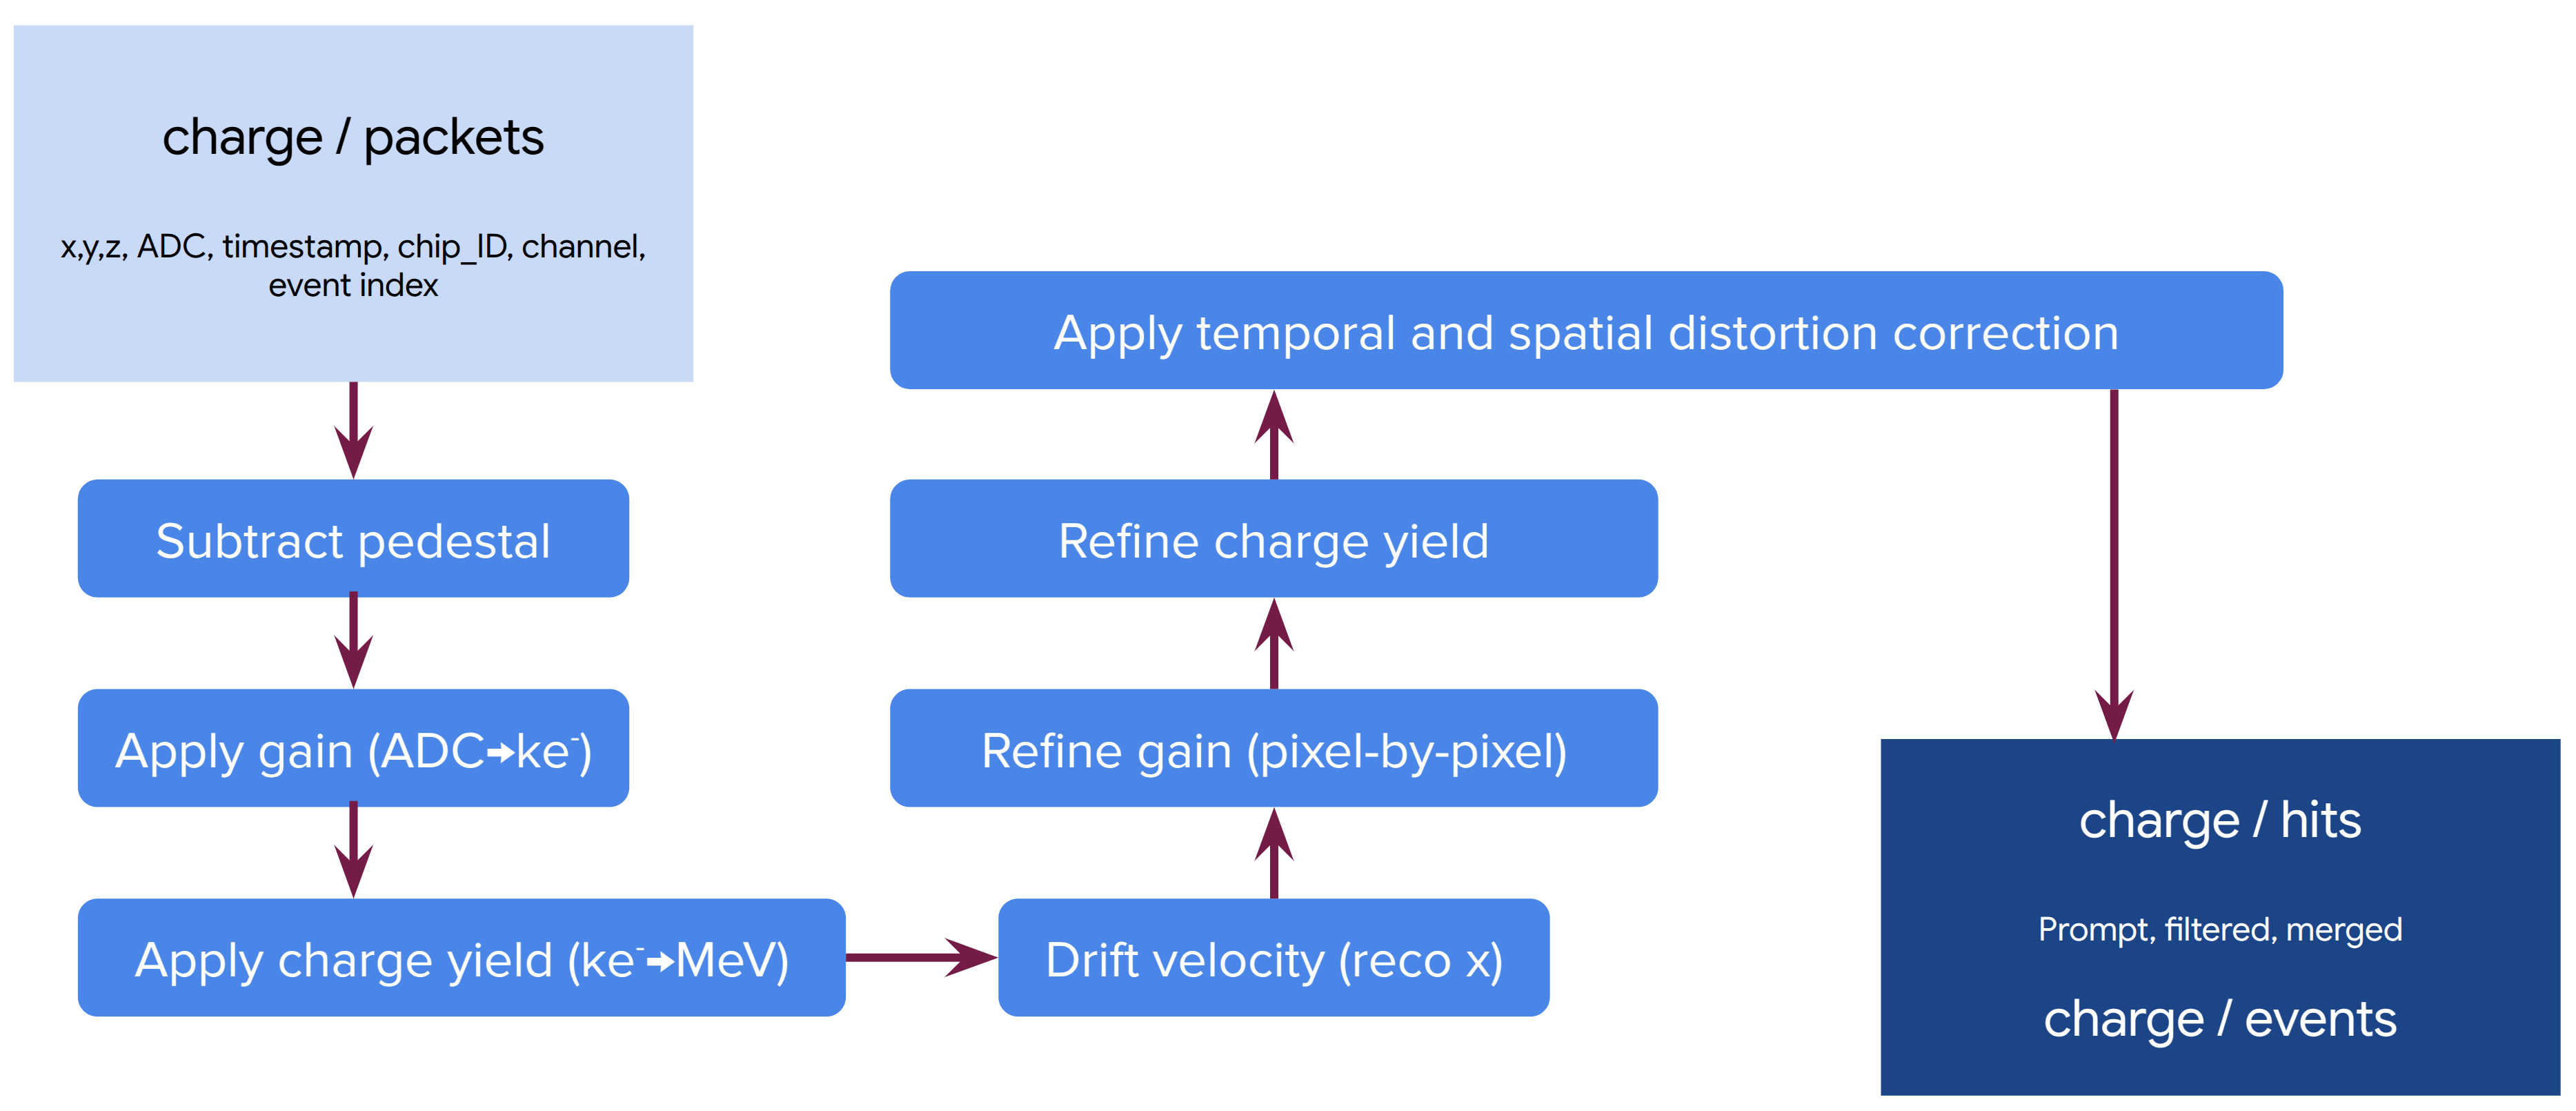

In [6]:
def fields_of(*paths):
    """Shape + field names of a `.../data` array."""
    for path in paths:
        dset = f_h5[path]
        print(f"{path}   {dset.shape}")
        if dset.dtype.names:
            print("    ", ", ".join(dset.dtype.names), "\n")

fields_of("charge/events/data",
          "charge/calib_prompt_hits/data",
          "charge/calib_final_hits/data")

charge/events/data   (188,)
     id, nhit, ADC, ts_start, ts_end, n_ext_trigs, unix_ts, unix_ts_usec 

charge/calib_prompt_hits/data   (152651,)
     id, x, y, z, t_drift, ts_pps, io_group, io_channel, chip_id, channel_id, Q_raw, Q, E, is_disabled 

charge/calib_final_hits/data   (118724,)
     id, x, y, z, t_drift, ts_pps, io_group, io_channel, chip_id, channel_id, Q_raw, Q, E, is_disabled 



### Coordinates and units — check before plotting

**x = drift**, **y = vertical**, **z = beam**.

| Quantity | Unit |
|---|---|
| `x,y,z` (hits, segments, trajectories, vertices) | cm |
| `Q`, `Q_raw` | ke⁻ |
| `E` (hits) | MeV |
| `dE`, `dEdx`, `dx` (segments) | MeV, MeV/cm, cm |
| `t_drift`, `ts_pps`, `ts_start` | CRS ticks of 0.1 µs |
| `t_ns` (light) | ns · one `wvfm` sample = 16 ns |
| `t_vert`, `t_event` | µs |

Hits and truth share a frame **within** a file — not across productions. Sanity-check every new sample:

In [7]:
hits = f_h5["charge/calib_final_hits/data"]
print(f"{len(hits):,} final hits\n")
for axis in "xyz":
    v = hits[axis]
    print(f"  {axis}  [{v.min():8.1f}, {v.max():8.1f}] cm   extent {v.max()-v.min():7.1f}")
print()
for field, unit in (("Q", "ke-"), ("E", "MeV"), ("t_drift", "ticks")):
    v = hits[field]
    print(f"  {field:8s} median {np.median(v):9.3f}  range [{v.min():.3f}, {v.max():.3f}] {unit}")

118,724 final hits

  x  [   -63.8,     63.8] cm   extent   127.5
  y  [   -61.9,     61.9] cm   extent   123.8
  z  [   -64.3,     64.3] cm   extent   128.7

  Q        median    14.927  range [1.145, 214.909] ke-
  E        median     0.526  range [0.039, 7.850] MeV
  t_drift  median   946.000  range [21.000, 2067.000] ticks


## 3 — Charge data

```
charge/packets            raw LArPix words (type 0 = data, 7 = trigger)
   -> charge/raw_hits            + pixel position
   -> charge/calib_prompt_hits   ADC->Q, t_drift->x.  ONE PER PACKET = the measurement
   -> charge/calib_final_hits    merged neighbours.   THE ANALYSIS PRODUCT
charge/events   one trigger/readout window        combined/t0   event time
```

In [8]:
for path in ("charge/raw_events", "charge/events", "charge/ext_trigs", "charge/packets",
             "charge/raw_hits", "charge/calib_prompt_hits", "charge/calib_final_hits",
             "combined/t0"):
    if f"{path}/data" in f_h5:
        print(f"  {path:32s} {len(f_h5[f'{path}/data']):>12,}")

n_prompt = len(f_h5["charge/calib_prompt_hits/data"])
n_final  = len(f_h5["charge/calib_final_hits/data"])
print(f"\n  merging: {n_final/n_prompt:.1%} as many final hits as prompt hits")

  charge/raw_events                         188
  charge/events                             188
  charge/ext_trigs                          188
  charge/packets                        304,313
  charge/raw_hits                       152,651
  charge/calib_prompt_hits              152,651
  charge/calib_final_hits               118,724
  combined/t0                               188

  merging: 77.8% as many final hits as prompt hits


188 events; fields: id, nhit, ADC, ts_start, ts_end, n_ext_trigs, unix_ts, unix_ts_usec
    id=0      nhit=412     ts_start=0.0
    id=1      nhit=382     ts_start=2000000.0
    id=2      nhit=598     ts_start=4000000.0


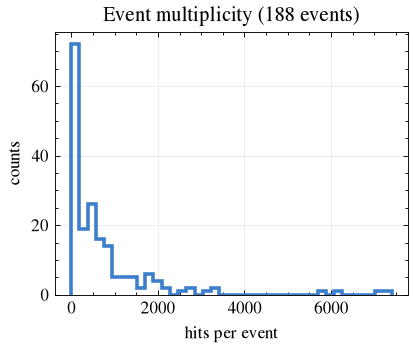

In [9]:
# events table + hit multiplicity
events = f_h5["charge/events/data"][:]
print(f"{len(events):,} events; fields: {', '.join(events.dtype.names)}")
for event in events[:3]:
    print(f"    id={event['id']:<6} nhit={event['nhit']:<7} ts_start={event['ts_start']}")

nhit = events["nhit"].astype(float)
fig, ax = plt.subplots()
ax.hist(nhit, bins=np.linspace(0, np.percentile(nhit, 99), 40),
        color=ONE_SERIES, histtype="step", lw=2)
ax.set(xlabel="hits per event", ylabel="counts", title=f"Event multiplicity ({len(events):,} events)")
plt.show()

### 3.1 Three ways to read the same hits

They return the **same hits with the same numbers** — what differs is the packaging,
and what you can do next with it.

| | Call | You get back | Use it for |
|---|---|---|---|
| **(a)** | `f_h5["charge/calib_final_hits/data"][:]` | the **whole file**, one plain structured array, in file row order | file-wide distributions |
| **(b)** | `f_manager["charge/events", "charge/calib_final_hits", i]` | **one event's hit data**, as a padded, masked `(1, max_nhit)` array | a quick per-event look, an event display |
| **(c)** | `dereference(..., indices_only=True)` | **the row numbers** of one event's hits | everything else |

Why (c) exists: (a) knows nothing about events, and (b) hands you values but not
*where they live in the file*. Only a row number lets you pull the same object out of
another table — which is exactly what truth matching needs, because the Part-5
backtracking tables are row-aligned with the hits. §3.2 puts the three side by side.

#### (a) Flat — the whole file at once

one hit: {'id': np.uint32(0), 'x': np.float64(3.2455049697539873), 'y': np.float64(-61.85430145263672), 'z': np.float64(38.15570068359375), 't_drift': np.float64(21.0), 'ts_pps': np.uint64(19), 'io_group': np.uint64(2), 'io_channel': np.uint64(25), 'chip_id': np.uint64(19), 'channel_id': np.uint64(63), 'Q_raw': np.float64(2.1987242572095758), 'Q': np.float64(2.1987242572095758), 'E': np.float64(0.07407016843554563), 'is_disabled': np.False_}


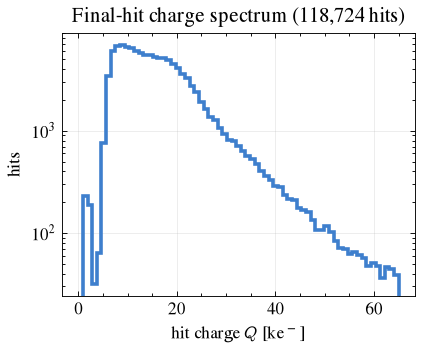

In [10]:
all_final_hits  = f_h5["charge/calib_final_hits/data"][:]
all_prompt_hits = f_h5["charge/calib_prompt_hits/data"][:]
print("one hit:", {k: all_final_hits[k][0] for k in all_final_hits.dtype.names})

charge = all_final_hits["Q"]
fig, ax = plt.subplots()
ax.hist(charge, bins=np.linspace(0, np.percentile(charge, 99.5), 70),
        color=ONE_SERIES, histtype="step", lw=2)
ax.set_yscale("log")
ax.set(xlabel=r"hit charge $Q$ [ke$^-$]", ylabel="hits",
       title=f"Final-hit charge spectrum ({len(charge):,} hits)")
plt.show()

#### (b) Per event, through the manager

`f_manager["charge/events", "charge/calib_final_hits", i]` walks `ref`/`ref_region` for you
and returns a **masked array** `(1, max_nhit)` — rectangular, so short events are padded.
**Always drop the mask before plotting**, or the fill values show up as a spike.

In [12]:
i_evt = 30

event_hits_masked = f_manager["charge/events", "charge/calib_final_hits", i_evt]
row = event_hits_masked[0]
is_real = ~np.ma.getmaskarray(row)["id"]      # getmaskarray: works when nothing is masked
event_hits = row[is_real]

print(f"shape {event_hits_masked.shape}  ->  {is_real.sum():,} real hits, "
      f"{(~is_real).sum():,} padding")
print(f"total charge {event_hits['Q'].sum():.1f} ke-")

shape (1, 1065)  ->  1,065 real hits, 0 padding
total charge 15692.7 ke-


#### (c) Row indices — the robust way

`dereference(..., indices_only=True)` returns row numbers instead of values. Those row
numbers are the currency: they index `data` *and* every row-aligned companion table
(Part 5). **`id` is not the row index** — the print below makes that concrete.

In [13]:
def event_rows(i_event, child, parent="charge/events"):
    """Row indices in <child>/data belonging to event i_event (padding removed)."""
    group = f_h5[f"{parent}/ref/{child}"]
    indices = dereference(i_event, ref=group["ref"], region=group["ref_region"],
                          ref_direction=(0, 1), indices_only=True)[0]
    return np.asarray(indices[~np.ma.getmaskarray(indices)], dtype=np.int64)


final_rows  = event_rows(i_evt, "charge/calib_final_hits")
prompt_rows = event_rows(i_evt, "charge/calib_prompt_hits")

final_hits_ev  = all_final_hits[final_rows]
prompt_hits_ev = all_prompt_hits[prompt_rows]

print(f"event {i_evt}: {len(final_rows)} final rows {final_rows[:6]}, "
      f"{len(prompt_rows)} prompt rows")
print(f"  their 'id' values: {all_final_hits['id'][final_rows][:6]}   <- NOT the row numbers")
print("  agrees with the manager read:",
      np.allclose(np.sort(final_hits_ev["z"]), np.sort(np.asarray(event_hits["z"]))))

event 30: 1065 final rows [30489 30490 30491 30492 30493 30494], 1419 prompt rows
  their 'id' values: [39500 39503 39504 39505 39509 39510]   <- NOT the row numbers
  agrees with the manager read: True


### 3.2 The three reads agree — check it once, then forget it

(b) and (c) select the same hits of event 30; (a) is the same hits *without* the event
grouping — and the rows claimed by all events put together rebuild it exactly.

In [14]:
# (b) manager read, padding already stripped above
hits_b = np.asarray(event_hits)
# (c) row indices used on the flat array of (a)
hits_c = all_final_hits[final_rows]

print(f"(b) {len(hits_b)} hits   (c) {len(hits_c)} hits")
for field in ("x", "y", "z", "Q", "E"):
    same = np.array_equal(np.sort(hits_b[field]), np.sort(hits_c[field]))
    print(f"    {field:>3s} identical: {same}")

# (a) has no events in it - but every event's rows together are exactly the flat array
all_rows = np.concatenate([event_rows(i, "charge/calib_final_hits") for i in range(len(events))])
print(f"\nrows claimed by the {len(events)} events : {len(all_rows):,}")
print(f"rows in the flat array           : {len(all_final_hits):,}")
print(f"each row used exactly once       : "
      f"{np.array_equal(np.sort(all_rows), np.arange(len(all_final_hits)))}")

(b) 1065 hits   (c) 1065 hits
      x identical: True
      y identical: True
      z identical: True
      Q identical: True
      E identical: True

rows claimed by the 188 events : 118,724
rows in the flat array           : 118,724
each row used exactly once       : True


### 3.3 Event display — two projections, coloured by charge
#### Also see larnddisplay.lbl.gov

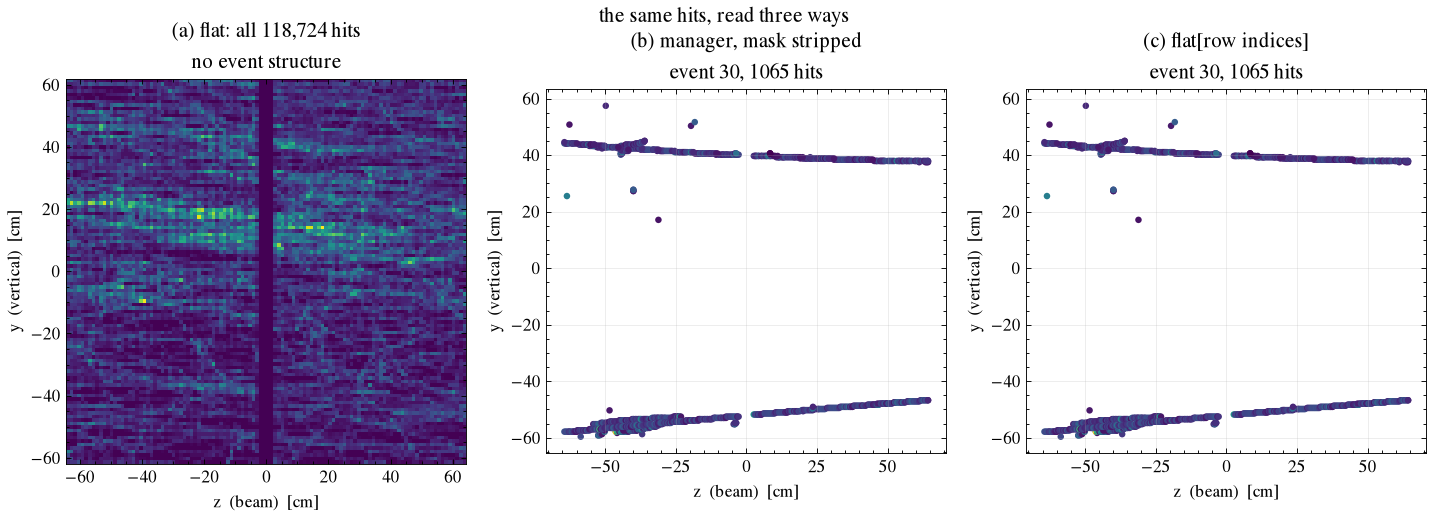

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2))

axes[0].hist2d(all_final_hits["z"], all_final_hits["y"], bins=110, cmap=SEQ_CMAP)
axes[0].grid(False)
axes[0].set_title(f"(a) flat: all {len(all_final_hits):,} hits\nno event structure")

for ax, hits_i, tag in ((axes[1], hits_b, "(b) manager, mask stripped"),
                        (axes[2], hits_c, "(c) flat[row indices]")):
    ax.scatter(hits_i["z"], hits_i["y"], c=hits_i["Q"], s=13, cmap=SEQ_CMAP, edgecolors="none")
    ax.set_title(f"{tag}\nevent {i_evt}, {len(hits_i)} hits")

for ax in axes:
    ax.set_xlabel("z  (beam)  [cm]")
    ax.set_ylabel("y  (vertical)  [cm]")
    ax.set_aspect("equal", adjustable="box")
axes[1].set_xlim(axes[2].get_xlim())
axes[1].set_ylim(axes[2].get_ylim())

plt.suptitle("the same hits, read three ways")
plt.show()

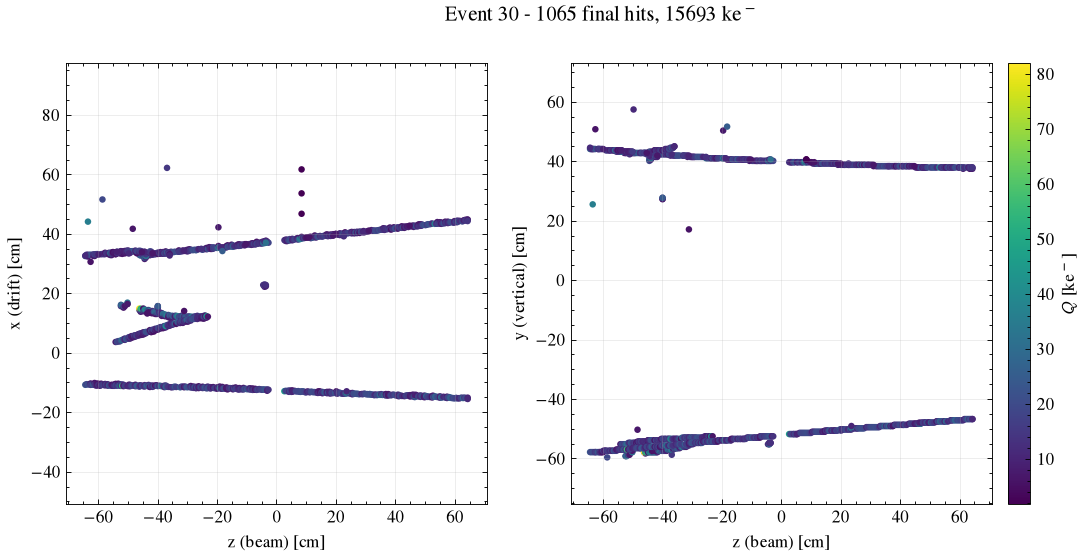

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.4))
for ax, (vertical, vlabel) in zip(axes, [("x", "x (drift) [cm]"), ("y", "y (vertical) [cm]")]):
    points = ax.scatter(final_hits_ev["z"], final_hits_ev[vertical], c=final_hits_ev["Q"],
                        s=13, cmap=SEQ_CMAP, edgecolors="none")
    ax.set_aspect("equal", adjustable="datalim")
    ax.set(xlabel="z (beam) [cm]", ylabel=vlabel)
fig.colorbar(points, ax=axes, pad=0.015).set_label(r"$Q$ [ke$^-$]")
plt.suptitle(f"Event {i_evt} - {len(final_hits_ev)} final hits, {final_hits_ev['Q'].sum():.0f} ke$^-$")
plt.show()

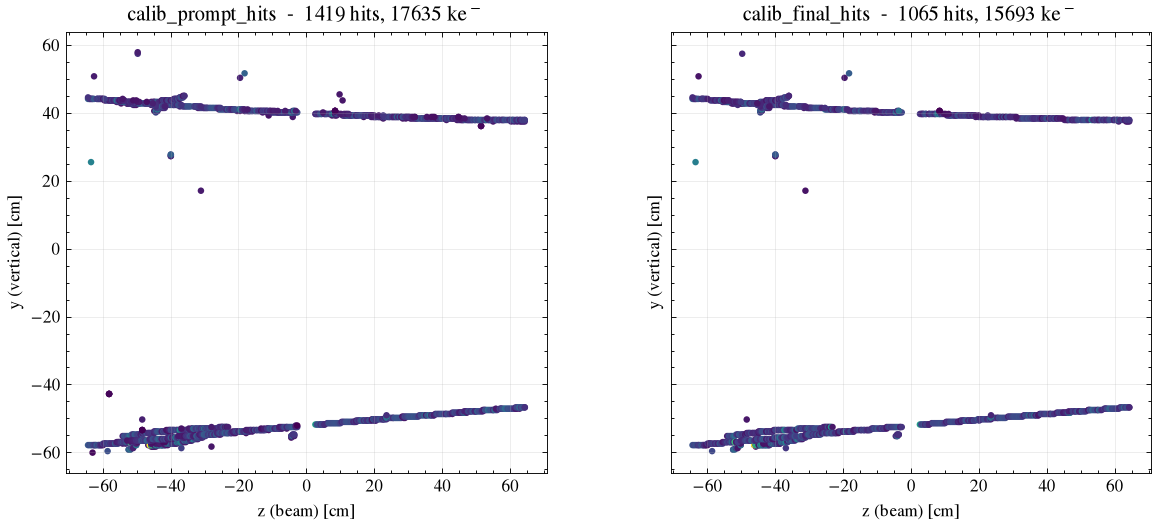

In [18]:
# what the filtering step did: prompt vs final, same event
fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.4), sharex=True, sharey=True)
for ax, hits_ev, name in ((axes[0], prompt_hits_ev, "calib_prompt_hits"),
                          (axes[1], final_hits_ev,  "calib_final_hits")):
    ax.scatter(hits_ev["z"], hits_ev["y"], c=hits_ev["Q"], s=13, cmap=SEQ_CMAP, edgecolors="none")
    ax.set_aspect("equal", adjustable="box")
    ax.set(xlabel="z (beam) [cm]", ylabel="y (vertical) [cm]",
           title=f"{name}  -  {len(hits_ev)} hits, {hits_ev['Q'].sum():.0f} ke$^-$")
plt.show()

## 4 — MC truth  *(simulation files only)*

| Dataset | One row is | Answers |
|---|---|---|
| `mc_truth/interactions` | a neutrino vertex (GENIE) | what event, where, Eν |
| `mc_truth/trajectories` | a particle (Geant4) | species, parent, energy |
| `mc_truth/segments` | an edep-sim step | where energy went, how much |

Nesting: interaction → trajectories → **segments**, and segments are what becomes charge.

**Identifier scope — the classic bug:**

| Field | Unique within | Join on it? |
|---|---|---|
| `event_id` | file | yes |
| `segment_id` | **file** | **yes** |
| `file_traj_id` | **file** | **yes** |
| `vertex_id` | an event | only with `event_id` |
| `traj_id` | **one interaction** | **no** — and `(event_id, traj_id)` is *still* ambiguous |

The last row is the one that bites. A spill (`event_id`) contains **several** interactions,
each numbering its particles from 1, so `(event_id, traj_id)` matches more than one
trajectory. You need `(event_id, vertex_id, traj_id)` — or, far simpler, the file-unique
`file_traj_id`, which `mc_truth/segments` carries for you. The next cell checks this on
your file.

In [19]:
interactions = trajectories = segments = None
if HAS_TRUTH:
    interactions = f_h5["mc_truth/interactions/data"][:]
    trajectories = f_h5["mc_truth/trajectories/data"][:]
    segments     = f_h5["mc_truth/segments/data"][:]
    for name, table in (("interactions", interactions), ("trajectories", trajectories),
                        ("segments", segments)):
        print(f"mc_truth/{name}: {len(table):,} rows\n    {', '.join(table.dtype.names)}\n")

    print("segment_id   unique in file:", len(np.unique(segments["segment_id"])) == len(segments))
    print("file_traj_id unique in file:", len(np.unique(trajectories["file_traj_id"])) == len(trajectories))
    print("traj_id      unique in file:", len(np.unique(trajectories["traj_id"])) == len(trajectories),
          "  <- if False, never join on traj_id alone")

    pair   = np.stack([trajectories["event_id"], trajectories["traj_id"]], axis=1)
    triple = np.stack([trajectories["event_id"], trajectories["vertex_id"],
                       trajectories["traj_id"]], axis=1)
    print("(event_id, traj_id)             unique:",
          len(np.unique(pair, axis=0)) == len(trajectories),
          "  <- False = several interactions per spill")
    print("(event_id, vertex_id, traj_id)  unique:",
          len(np.unique(triple, axis=0)) == len(trajectories))
    print(f"interactions per spill: {len(interactions) / len(np.unique(interactions['event_id'])):.1f}")
else:
    print("[skipped] no mc_truth - this is detector data. Parts 4-5 need simulation.")

mc_truth/interactions: 719 rows
    t_event, event_id, f2, vertex_id, x_vert, y_vert, z_vert, f7, t_vert, target, reaction, isCC, isQES, isMEC, isRES, isDIS, isCOH, f17, Enu, nu_4mom, nu_pdg, Elep, lep_mom, lep_ang, lep_pdg, q0, q3, Q2, x, y, f30

mc_truth/trajectories: 114,242 rows
    event_id, vertex_id, traj_id, file_traj_id, parent_id, primary, E_start, pxyz_start, xyz_start, t_start, E_end, pxyz_end, xyz_end, t_end, KE_start, KE_end, pdg_id, start_process, start_subprocess, end_process, end_subprocess, dist_travel

mc_truth/segments: 133,643 rows
    event_id, vertex_id, segment_id, z_end, traj_id, file_traj_id, tran_diff, z_start, x_end, y_end, n_electrons, pdg_id, x_start, y_start, t_start, t0_start, t0_end, t0, dx, long_diff, pixel_plane, t, t_end, dEdx, dE, dE_secondary, y, x, z, n_photons

segment_id   unique in file: True
file_traj_id unique in file: True
traj_id      unique in file: False   <- if False, never join on traj_id alone
(event_id, traj_id)             unique: Fa

### 4.1 Interactions — fields depend on the production

Vertex: `x_vert/y_vert/z_vert` [cm] (MiniRun5-beta2+) **or** a single `vertex` `(N,3)` array (older).
`Enu`, `isCC`, `reaction`, `Elep`... exist only in **neutrino** samples.

In [20]:
vertex_xyz = None
if HAS_TRUTH and len(interactions):
    fields = set(interactions.dtype.names)
    if {"x_vert", "y_vert", "z_vert"} <= fields:
        vertex_xyz = np.stack([interactions[f"{a}_vert"] for a in "xyz"], axis=1)
    elif "vertex" in fields:
        vertex_xyz = np.asarray(interactions["vertex"])
    if vertex_xyz is not None:
        for axis, name in enumerate("xyz"):
            print(f"  {name}_vert [{vertex_xyz[:, axis].min():8.1f}, {vertex_xyz[:, axis].max():8.1f}] cm")

    present = [f for f in ("Enu", "isCC", "reaction", "Elep", "nu_pdg", "target", "q2") if f in fields]
    print("\nneutrino kinematics fields:", present or "none (particle gun / cosmics)")

  x_vert [  -741.4,    706.5] cm
  y_vert [  -398.7,    973.2] cm
  z_vert [ -9747.1,    999.0] cm

neutrino kinematics fields: ['Enu', 'isCC', 'reaction', 'Elep', 'nu_pdg', 'target']


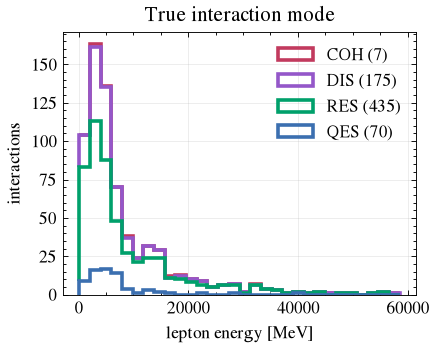

In [21]:
# interaction modes - neutrino samples only
REACTION_NAMES = {1: "QES", 2: "MEC", 3: "RES", 4: "DIS", 5: "COH"}

if HAS_TRUTH and {"reaction", "Elep"} <= set(interactions.dtype.names):
    series, labels_, colors = [], [], []
    for slot, (code, name) in enumerate(sorted(REACTION_NAMES.items())):
        selected = interactions[interactions["reaction"] == code]["Elep"]
        if len(selected):
            series.append(selected); labels_.append(f"{name} ({len(selected):,})")
            colors.append(CATEGORICAL[slot % len(CATEGORICAL)])
    fig, ax = plt.subplots()
    ax.hist(series, bins=30, stacked=True, histtype="step", lw=2, color=colors, label=labels_)
    ax.legend(frameon=False)
    ax.set(xlabel="lepton energy [MeV]", ylabel="interactions", title="True interaction mode")
    plt.show()
else:
    print("[skipped] no reaction/Elep in this sample.")

## 5 — Truth ↔ hits 

```
segments (dE, dx) --larnd-sim--> drift --> charge/packets   <-- truth attached HERE
      -> calib_prompt_hits -> calib_final_hits 
```

Many-to-many: one hit has **several** contributing segments, one segment feeds several hits.
So a hit's truth is a **weighted list, not a label** — that list is the backtracking table.

| Backtrack dataset | Row-aligned with |
|---|---|
| `mc_truth/calib_prompt_hit_backtrack` | `charge/calib_prompt_hits/data` |
| `mc_truth/calib_final_hit_backtrack`  | `charge/calib_final_hits/data` |

Row *k* describes hit row *k*. Fields (fixed-length, padded with `-1`/`0`):
`segment_ids`, `fraction` (share of **this hit's** charge), `file_traj_ids`,
`fraction_traj`, `event_ids`.

> **Trap 1** — `segment_ids` holds `segment_id` **values**, not row numbers. Look them up.
>
> **Trap 2** — `file_traj_ids` does **not** hold `file_traj_id`. It holds `traj_id`,
> which is unique only inside **one interaction** — and a spill holds several. So even
> `(event_ids, file_traj_ids)` matches the wrong particle a good fraction of the time.
>
> Both fail **silently**: you get a plausible wrong particle, no exception.

**The route that always works** goes through the segments, because every id on it is
file-unique: hit → `segment_ids` → `mc_truth/segments` → `file_traj_id` → `trajectories`.
That is what §5.2 implements, and the next cell measures how wrong the shortcuts are.

In [22]:
backtrack_final = backtrack_prompt = None
if HAS_TRUTH:
    backtrack_final  = f_h5["mc_truth/calib_final_hit_backtrack/data"][:]
    backtrack_prompt = f_h5["mc_truth/calib_prompt_hit_backtrack/data"][:]
    for field in backtrack_final.dtype.names:
        print(f"    {field:<16} {backtrack_final.dtype[field]}")

    print("\nrow-aligned with the hits:",
          len(backtrack_final) == len(all_final_hits),
          "/", len(backtrack_prompt) == len(all_prompt_hits))
    n_links = (backtrack_final["fraction"] > 0).sum(axis=1)
    print(f"slots per hit {backtrack_final['segment_ids'].shape[1]} | "
          f"segments per hit: median {int(np.median(n_links))}, max {n_links.max()}, "
          f"none: {(n_links == 0).sum():,}")

    event_ids        ('<i8', (1,))
    segment_ids      ('<i8', (20,))
    fraction         ('<f8', (20,))
    file_traj_ids    ('<i8', (20,))
    fraction_traj    ('<f8', (20,))

row-aligned with the hits: True / True
slots per hit 20 | segments per hit: median 4, max 20, none: 158


### 5.1 Lookups

Truth is joined on **identifier fields**, not on references: the backtrack tables store
`segment_id` *values*, so you have to look them up whatever references exist. (This file
does store `trajectories → segments`; some productions do not — check the map in §2.)

`make_lookup` sorts a key column once, then answers many queries at once; it also tells
you which keys it failed to find, rather than returning something plausible.

In [23]:
def make_lookup(keys):
    """values -> (row indices, found mask), via a sorted index. Works on any shape."""
    order = np.argsort(keys)
    sorted_keys = keys[order]
    def lookup(values):
        values = np.asarray(values)
        position = np.clip(np.searchsorted(sorted_keys, values), 0, len(sorted_keys) - 1)
        return order[position], sorted_keys[position] == values
    return lookup


def make_key_lookup(*key_columns):
    """Same, for a key made of several fields, packed into one integer."""
    strides = [np.int64(int(np.max(column)) + 1) for column in key_columns]
    def pack(columns):
        packed = np.zeros(np.shape(columns[0]), dtype=np.int64)
        for column, stride in zip(columns, strides):
            packed = packed * stride + np.asarray(column, dtype=np.int64)
        return packed
    inner = make_lookup(pack(key_columns))
    return lambda *values: inner(pack(values))


if HAS_TRUTH:
    # file-unique keys: these two are the ones to build an analysis on
    segment_lookup    = make_lookup(segments["segment_id"])
    trajectory_lookup = make_lookup(trajectories["file_traj_id"])

    # what the backtrack table pushes you towards - ambiguous, kept to demonstrate it
    trajectory_pair_lookup = make_key_lookup(trajectories["event_id"],
                                             trajectories["traj_id"])
    # the same thing disambiguated by the interaction
    trajectory_vertex_lookup = make_key_lookup(trajectories["event_id"],
                                               trajectories["vertex_id"],
                                               trajectories["traj_id"])
    interaction_lookup = make_key_lookup(interactions["event_id"],
                                         interactions["vertex_id"])
    print("lookups built.")

lookups built.


In [24]:
# Which route gets the right particle? Reference = the pdg of the hit's dominant SEGMENT,
# which is unambiguous because segment_id is file-unique.
if HAS_TRUTH:
    rows = np.arange(len(backtrack_final))

    frac_seg = backtrack_final["fraction"]
    best_seg = np.argmax(np.where(frac_seg > 0, frac_seg, -1.0), axis=1)
    seg_rows, seg_ok = segment_lookup(backtrack_final["segment_ids"][rows, best_seg])
    dominant_seg = segments[seg_rows]
    true_pdg = dominant_seg["pdg_id"]

    frac_traj = backtrack_final["fraction_traj"]
    used_traj = frac_traj > 0
    best_traj = np.argmax(np.where(used_traj, frac_traj, -1.0), axis=1)
    traj_field = backtrack_final["file_traj_ids"][rows, best_traj]
    event_ids  = backtrack_final["event_ids"][:, 0]

    good = used_traj.any(axis=1) & seg_ok

    readings = [
        ("as file_traj_id (what the name says)", trajectory_lookup(traj_field)),
        ("as (event_id, traj_id)", trajectory_pair_lookup(event_ids, traj_field)),
        ("as (event_id, vertex_id, traj_id)",
         trajectory_vertex_lookup(event_ids, dominant_seg["vertex_id"], traj_field)),
        ("via the segment's own file_traj_id",
         trajectory_lookup(dominant_seg["file_traj_id"])),
    ]

    print(f"{'reading':38s} {'join found':>11s} {'pdg agrees':>11s}")
    print("-" * 62)
    for name, (traj_rows, found) in readings:
        sel = good & found
        agrees = np.mean(trajectories["pdg_id"][traj_rows][sel] == true_pdg[sel])
        print(f"{name:38s} {found[good].mean():>11.3f} {agrees:>11.3f}")

    print("\nA join that 'succeeds' is not a join that is right: the middle rows find a")
    print("trajectory for every hit and still return the wrong particle.")
    print(f"backtrack event_ids == dominant segment's event_id: "
          f"{np.mean(event_ids[good] == dominant_seg['event_id'][good]):.3f}")

reading                                 join found  pdg agrees
--------------------------------------------------------------
as file_traj_id (what the name says)         0.509       0.162
as (event_id, traj_id)                       1.000       0.666
as (event_id, vertex_id, traj_id)            1.000       0.950
via the segment's own file_traj_id           1.000       1.000

A join that 'succeeds' is not a join that is right: the middle rows find a
trajectory for every hit and still return the wrong particle.
backtrack event_ids == dominant segment's event_id: 1.000


### 5.2 The recipe — copy this into your analysis

`truth_label_hits(hit_rows, backtrack_table)` → one truth label per hit.

In [25]:
def truth_label_hits(hit_rows, backtrack_table):
    """Per-hit truth, resolved through the SEGMENTS - every id on that route is file-unique.

    Returns arrays of len(hit_rows):
        pdg           PDG of the particle contributing most of the hit's charge (0 if none)
        file_traj_id  that particle, file-unique (-1 if unmatched)
        traj_id, vertex_id, event_id   its bookkeeping ids (-1 if unmatched)
        purity        that particle's share of the hit's charge
        n_particles   how many distinct particles contributed
        matched       False where no truth could be attached
    """
    backtrack = backtrack_table[hit_rows]
    fraction = backtrack["fraction"]                       # share per contributing SEGMENT
    n_hits, n_slots = fraction.shape

    # every slot: segment_id value -> segments row -> the particle that owns that segment
    seg_rows, seg_found = segment_lookup(backtrack["segment_ids"])
    ok = (fraction > 0) & seg_found
    particle = np.where(ok, segments["file_traj_id"][seg_rows], -1)

    # sum each particle's slots, so the label is "most charge", not "biggest single segment"
    totals = np.zeros_like(fraction)
    is_first = np.zeros_like(ok)
    for slot in range(n_slots):
        same = ok & (particle == particle[:, [slot]])
        totals[:, slot] = np.where(same, fraction, 0.0).sum(axis=1)
        is_first[:, slot] = ok[:, slot] & ~same[:, :slot].any(axis=1)

    rows = np.arange(n_hits)
    best = np.argmax(np.where(ok, totals, -1.0), axis=1)
    matched = ok.any(axis=1)

    file_traj_id = np.where(matched, particle[rows, best], -1)
    best_seg_row = seg_rows[rows, best]

    pdg = np.zeros(n_hits, dtype=np.int64)
    traj_rows, found = trajectory_lookup(np.where(matched, file_traj_id, -1))
    good = matched & found
    pdg[good] = trajectories["pdg_id"][traj_rows[good]]

    return {"pdg": pdg,
            "file_traj_id": file_traj_id,
            "traj_id":   np.where(matched, segments["traj_id"][best_seg_row], -1),
            "vertex_id": np.where(matched, segments["vertex_id"][best_seg_row], -1),
            "event_id":  np.where(matched, segments["event_id"][best_seg_row], -1),
            "purity": np.where(matched, totals[rows, best], 0.0),
            "n_particles": is_first.sum(axis=1),
            "matched": good}


def dominant_segment_rows(hit_rows, backtrack_table):
    """Rows in `segments` of each hit's largest-fraction contributor -> (rows, ok)."""
    backtrack = backtrack_table[hit_rows]
    fraction = backtrack["fraction"]
    used = fraction > 0
    best_slot = np.argmax(np.where(used, fraction, -1.0), axis=1)
    segment_ids = backtrack["segment_ids"][np.arange(len(hit_rows)), best_slot]
    rows, found = segment_lookup(segment_ids)        # VALUES, not row numbers (trap 1)
    return rows, found & used.any(axis=1)


PDG_NAMES = {11: "e-", -11: "e+", 12: "nu_e", -12: "anu_e", 13: "mu-", -13: "mu+",
             14: "nu_mu", -14: "anu_mu", 22: "gamma", 111: "pi0", 211: "pi+", -211: "pi-",
             321: "K+", -321: "K-", 130: "K0L", 310: "K0S", 2112: "n", 2212: "p",
             -2212: "pbar", 1000010020: "d", 1000020040: "alpha"}
pdg_name = lambda code: PDG_NAMES.get(int(code), f"pdg {int(code)}")

if HAS_TRUTH:
    labels = truth_label_hits(final_rows, backtrack_final)
    print(f"event {i_evt}: {labels['matched'].sum()}/{len(final_rows)} hits matched, "
          f"median purity {np.median(labels['purity'][labels['matched']]):.2f}, "
          f"median contributors {int(np.median(labels['n_particles']))}")
    codes, counts = np.unique(labels["pdg"][labels["matched"]], return_counts=True)
    for code, count in sorted(zip(codes, counts), key=lambda t: -t[1])[:6]:
        print(f"    {pdg_name(code):>8s}  {count:5d} hits")

event 30: 1065/1065 hits matched, median purity 1.00, median contributors 1
         mu-    365 hits
         mu+    346 hits
         pi-    212 hits
          e-    135 hits
          e+      7 hits


### 5.3 Event display coloured by **true species**, truth segments overlaid

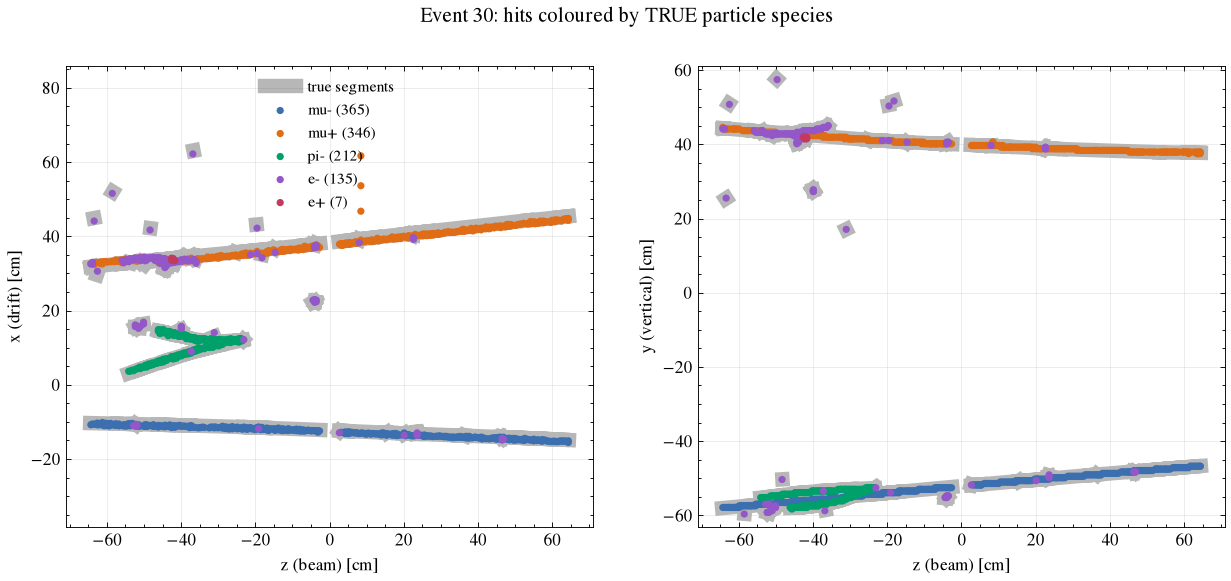

In [26]:
if HAS_TRUTH and len(final_hits_ev):
    codes, counts = np.unique(labels["pdg"][labels["matched"]], return_counts=True)
    ranked = codes[np.argsort(counts)[::-1]]                       # abundance order = stable colours
    colour_of = {code: CATEGORICAL[i] for i, code in enumerate(ranked[:5])}

    seg_rows, seg_ok = dominant_segment_rows(final_rows, backtrack_final)
    truth_segments = segments[np.unique(seg_rows[seg_ok])]
    nan_pad = np.full(len(truth_segments), np.nan)

    fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.6))
    for ax, (vertical, vlabel) in zip(axes, [("x", "x (drift) [cm]"), ("y", "y (vertical) [cm]")]):
        first = vertical == "x"
        ax.plot(np.column_stack([truth_segments["z_start"], truth_segments["z_end"], nan_pad]).ravel(),
                np.column_stack([truth_segments[f"{vertical}_start"],
                                 truth_segments[f"{vertical}_end"], nan_pad]).ravel(),
                color="#333333", lw=8, alpha=0.35, zorder=1,
                label="true segments" if first else None)

        for code in ranked:
            sel = labels["pdg"] == code
            ax.scatter(final_hits_ev["z"][sel], final_hits_ev[vertical][sel], s=16, zorder=2,
                       color=colour_of.get(code, NEUTRAL), edgecolors="none",
                       label=f"{pdg_name(code)} ({sel.sum()})" if first else None)

        unmatched = ~labels["matched"]
        if unmatched.any():
            ax.scatter(final_hits_ev["z"][unmatched], final_hits_ev[vertical][unmatched],
                       s=16, color=NEUTRAL, marker="x", zorder=2,
                       label=f"unmatched ({unmatched.sum()})" if first else None)

        ax.set_aspect("equal", adjustable="datalim")
        ax.set(xlabel="z (beam) [cm]", ylabel=vlabel)

    axes[0].legend(frameon=False, fontsize=8.5)
    fig.suptitle(f"Event {i_evt}: hits coloured by TRUE particle species")
    plt.show()

Grey lines = what the simulation said happened. Dots = what was reconstructed, painted with
the identity of the particle that gave most of the charge. **If a hit does not sit on its
segment, the matching is wrong — and nothing raises.**

## 6 — Example analysis: dE/dx from pixel hits

The first real measurement you can make from `calib_final_hits`: **energy deposited per
unit length along a track**. Four steps:

1. **select** the hits of one track (one true particle if you have truth, the event if not);
2. **fit its axis** — the first principal component of the hit positions;
3. **project** every hit onto that axis → a coordinate `s` in cm;
4. **bin** in `s` and divide: `dE/dx = ΣE_bin / Δs` in MeV/cm.

Before you quote a number:

* `E` in `calib_*_hits` is the flow's **reconstructed deposited energy** [MeV]: ADC → `Q`
  → recombination and W-value correction, with *your production's* calibration constants.
  It is not truth — §6.2 compares it against the true segments.
* the pixel pitch (~4.4 mm) sets the resolution: bins below ~1 cm measure granularity,
  not physics.
* dx is the projection onto a **straight** axis, so reject curved / overlapping candidates
  (the straightness cut) and drop the first and last bin, which are partial.
* the distribution is **Landau-like** — quote the MPV, not the mean.
* reference point: a minimum-ionising particle in liquid argon is **≈ 2.1 MeV/cm**.

In [ ]:
MIP_DEDX = 2.1          # MeV/cm, minimum-ionising particle in liquid argon


def track_axis(xyz):
    """Principal axis of a hit cloud -> (centroid, unit axis, straightness).

    straightness = fraction of the variance on the leading component; ~1 for a clean
    straight track, well below for a shower or two overlapping tracks.
    """
    centroid = xyz.mean(axis=0)
    _, singular, components = np.linalg.svd(xyz - centroid, full_matrices=False)
    return centroid, components[0], singular[0] ** 2 / np.sum(singular ** 2)


def dedx_profile(hits, bin_cm=1.0, trim=1, min_n=1):
    """dE/dx along the track's principal axis, or None if the track is too short.

    Returns a dict:
        s, dedx        bin centre [cm], summed hit E / bin width [MeV/cm]
        n              hits in the bin
        keep           which of the full set of bins survived the trim
        straightness   from track_axis
        s_hit, edges   per-hit coordinate along the axis, and the bin edges
        centroid, axis the fitted line
    `trim` drops that many bins at each end: they are partial, so biased low.
    `min_n` drops bins with fewer than that many hits - they are granularity, not dE/dx.
    """
    xyz = np.stack([hits["x"], hits["y"], hits["z"]], axis=1).astype(float)
    centroid, axis, straightness = track_axis(xyz)

    s_hit = (xyz - centroid) @ axis          # cm along the axis
    s_hit -= s_hit.min()

    edges = np.arange(0.0, s_hit.max() + bin_cm, bin_cm)
    if len(edges) < 2 * trim + 2:
        return None

    energy_sum, _ = np.histogram(s_hit, bins=edges, weights=hits["E"].astype(float))
    n_per_bin, _  = np.histogram(s_hit, bins=edges)

    centers = 0.5 * (edges[:-1] + edges[1:])
    keep = n_per_bin >= min_n
    keep[:trim] = False
    keep[len(centers) - trim:] = False

    return {"s": centers[keep], "dedx": energy_sum[keep] / bin_cm, "n": n_per_bin[keep],
            "straightness": straightness, "s_hit": s_hit, "edges": edges, "keep": keep,
            "centroid": centroid, "axis": axis}


def track_candidates(hit_rows, backtrack_table=None, min_hits=25):
    """Split a set of hit rows into track candidates.

    With truth: one candidate per true particle, grouped on file_traj_id (the FILE-unique
    id - see trap 2 in 5.2). Without truth: the whole set as one candidate.
    Yields (label, rows).
    """
    if backtrack_table is None:
        if len(hit_rows) >= min_hits:
            yield "all hits", hit_rows
        return

    truth = truth_label_hits(hit_rows, backtrack_table)
    for particle in np.unique(truth["file_traj_id"][truth["matched"]]):
        belongs = truth["file_traj_id"] == particle
        if belongs.sum() < min_hits:
            continue
        yield f"{pdg_name(truth['pdg'][belongs][0])} (file_traj_id {particle})", hit_rows[belongs]


print(f"dE/dx helpers ready. MIP reference {MIP_DEDX} MeV/cm.")

### 6.1 One track: hits, fitted axis, dE/dx profile

The longest candidate in our event — one true particle if the file has truth.

In [ ]:
BIN_CM = 1.0        # bin width along the track [cm]

candidates = list(track_candidates(final_rows, backtrack_final if HAS_TRUTH else None))
if not candidates:                         # nothing long enough: fall back to the event
    candidates = [("all hits", final_rows)]
# rank by (is it straight enough to have a dx at all, then how many hits)
scored = []
for label_i, rows_i in candidates:
    profile_i = dedx_profile(all_final_hits[rows_i], bin_cm=BIN_CM)
    if profile_i is not None:
        scored.append((profile_i["straightness"] >= 0.95, len(rows_i), label_i, rows_i, profile_i))
assert scored, "no candidate long enough - lower MIN_HITS or BIN_CM"
scored.sort(key=lambda item: (item[0], item[1]), reverse=True)
is_straight, _, name, track_rows, prof = scored[0]

track_hits = all_final_hits[track_rows]
if not is_straight:
    print("!! no straight candidate: the projection below is not a real path length")

print(f"event {i_evt}: {len(candidates)} candidate(s), using {name}")
print(f"  {len(track_hits)} hits | length {prof['s_hit'].max():.1f} cm | "
      f"straightness {prof['straightness']:.4f} | "
      f"total {track_hits['E'].sum():.1f} MeV / {track_hits['Q'].sum():.0f} ke-")

# the track, with the axis we fitted to it
xyz = np.stack([track_hits[a] for a in "xyz"], axis=1).astype(float)
centroid, axis = prof["centroid"], prof["axis"]
span = np.array([((xyz - centroid) @ axis).min(), ((xyz - centroid) @ axis).max()])

fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.4))
for ax, (vertical, vlabel) in zip(axes, [("x", "x  (drift)  [cm]"), ("y", "y  (vertical)  [cm]")]):
    points = ax.scatter(track_hits["z"], track_hits[vertical], c=track_hits["E"],
                        s=13, cmap=SEQ_CMAP, edgecolors="none", zorder=2)
    ax.plot(centroid[2] + span * axis[2],
            centroid["xyz".index(vertical)] + span * axis["xyz".index(vertical)],
            color=NEUTRAL, lw=1.2, ls="--", zorder=1, label="fitted axis")
    ax.set_aspect("equal", adjustable="datalim")
    ax.set_xlabel("z  (beam)  [cm]")
    ax.set_ylabel(vlabel)
axes[0].legend(frameon=False)
bar = fig.colorbar(points, ax=axes, pad=0.015)
bar.set_label(r"hit energy $E$  [MeV]")
plt.suptitle(f"Event {i_evt} - {name}")
plt.show()

In [ ]:
fig, ax = plt.subplots()
ax.step(prof["s"], prof["dedx"], where="mid", color=ONE_SERIES, lw=2, label="reconstructed")
ax.axhline(MIP_DEDX, color=NEUTRAL, ls="--", lw=1.2, label=f"MIP {MIP_DEDX} MeV/cm")
ax.legend(frameon=False)
ax.set_xlabel("distance along the track  $s$  [cm]")
ax.set_ylabel(r"$dE/dx$  [MeV/cm]")
plt.title(f"Event {i_evt}, {name}  -  {BIN_CM:.0f} cm bins")
plt.show()

print(f"median dE/dx {np.median(prof['dedx']):.2f} MeV/cm over {len(prof['dedx'])} bins "
      f"({prof['n'].mean():.1f} hits/bin)")

### 6.2 Reconstructed vs **true** dE/dx

Part 5 gives each hit its dominant `mc_truth/segments` row, and a segment carries the
true `dE` and `dx`. Binning those the same way puts truth and reconstruction on the same
axes — this is the plot that tells you whether your calibration is doing its job.

(Each bin is the *hit-weighted* mean of the true segment dE/dx: a segment dominant for
several hits enters both sums several times. Bins with one or two hits are noise —
the ratio below only uses bins with ≥ 3.)

In [ ]:
if HAS_TRUTH:
    seg_rows, seg_ok = dominant_segment_rows(track_rows, backtrack_final)
    seg = segments[seg_rows]
    edges = prof["edges"]
    centers = 0.5 * (edges[:-1] + edges[1:])
    seg_fields = set(segments.dtype.names)

    if {"dE", "dx"} <= seg_fields:
        dE_sum, _ = np.histogram(prof["s_hit"][seg_ok], bins=edges,
                                 weights=seg["dE"][seg_ok].astype(float))
        dx_sum, _ = np.histogram(prof["s_hit"][seg_ok], bins=edges,
                                 weights=seg["dx"][seg_ok].astype(float))
        true_dedx = np.where(dx_sum > 0, dE_sum / np.where(dx_sum > 0, dx_sum, 1), np.nan)
    else:                                   # fall back on the stored dEdx
        w, _ = np.histogram(prof["s_hit"][seg_ok], bins=edges,
                            weights=seg["dEdx"][seg_ok].astype(float))
        n, _ = np.histogram(prof["s_hit"][seg_ok], bins=edges)
        true_dedx = np.where(n > 0, w / np.where(n > 0, n, 1), np.nan)

    fig, ax = plt.subplots()
    ax.step(centers, true_dedx, where="mid", color=CATEGORICAL[1], lw=2, label="true (segments)")
    ax.step(prof["s"], prof["dedx"], where="mid", color=ONE_SERIES, lw=2, label="reconstructed")
    ax.axhline(MIP_DEDX, color=NEUTRAL, ls="--", lw=1.2, label=f"MIP {MIP_DEDX} MeV/cm")
    ax.legend(frameon=False)
    ax.set_xlabel("distance along the track  $s$  [cm]")
    ax.set_ylabel(r"$dE/dx$  [MeV/cm]")
    plt.title(f"Event {i_evt}, {name}  -  reco vs truth")
    plt.show()

    # compare only bins with enough hits - a 1-hit bin says nothing
    true_kept = true_dedx[prof["keep"]]             # same bins as prof["dedx"]
    both = np.isfinite(true_kept) & (true_kept > 0) & (prof["n"] >= 3)
    if both.sum() >= 3:
        ratio = prof["dedx"][both] / true_kept[both]
        print(f"reco / true dE/dx over {both.sum()} bins: median {np.median(ratio):.2f}, "
              f"16-84% {np.percentile(ratio, 16):.2f}-{np.percentile(ratio, 84):.2f}")
        print("  (that ratio is your calibration closure: recombination + lifetime + gain)")
    else:
        print("too few bins with >=3 hits to quote a ratio - use a longer track or a wider BIN_CM")
else:
    print("[skipped] needs mc_truth.")

### 6.3 The dE/dx distribution over many tracks

Loop over events, keep straight candidates only, collect every bin. This is the
Landau-like spectrum you would calibrate against — and its MPV is a number you can
compare with 2.1 MeV/cm. A MPV well below that is telling you something — about the
calibration, about thresholds, or about the binning — not about the argon.

In [ ]:
N_EVENTS_SCAN  = 200      # raise for statistics (this file has 188 events)
MIN_HITS       = 25       # hits per track candidate
MIN_STRAIGHT   = 0.99     # variance fraction on the leading axis
MIN_LENGTH_CM  = 5.0

dedx_all, dedx_by_species, length_all = [], {}, []
n_events_total = len(f_h5["charge/events/data"])

for i_event in range(min(N_EVENTS_SCAN, n_events_total)):
    rows = event_rows(i_event, "charge/calib_final_hits")
    if len(rows) < MIN_HITS:
        continue
    for label, rows_i in track_candidates(rows, backtrack_final if HAS_TRUTH else None,
                                          min_hits=MIN_HITS):
        profile_i = dedx_profile(all_final_hits[rows_i], bin_cm=BIN_CM)
        if profile_i is None or profile_i["straightness"] < MIN_STRAIGHT:
            continue
        length = profile_i["s_hit"].max() - profile_i["s_hit"].min()
        if length < MIN_LENGTH_CM:
            continue
        dedx_all.append(profile_i["dedx"])
        length_all.append(length)
        dedx_by_species.setdefault(label.split(" (")[0], []).append(profile_i["dedx"])

dedx_all = np.concatenate(dedx_all) if dedx_all else np.array([])
print(f"{len(length_all):,} tracks, {len(dedx_all):,} dE/dx bins "
      f"from {min(N_EVENTS_SCAN, n_events_total)} events")

if len(dedx_all):
    bins = np.linspace(0, np.percentile(dedx_all, 99), 60)
    counts, edges_h = np.histogram(dedx_all, bins=bins)
    mpv = 0.5 * (edges_h[np.argmax(counts)] + edges_h[np.argmax(counts) + 1])

    fig, ax = plt.subplots()
    ax.hist(dedx_all, bins=bins, color=ONE_SERIES, histtype="step", lw=2)
    ax.axvline(mpv, color=CATEGORICAL[1], ls="-", lw=1.4, label=f"MPV {mpv:.2f} MeV/cm")
    ax.axvline(MIP_DEDX, color=NEUTRAL, ls="--", lw=1.2, label=f"MIP {MIP_DEDX} MeV/cm")
    ax.legend(frameon=False)
    ax.set_xlabel(r"$dE/dx$  [MeV/cm]")
    ax.set_ylabel(f"bins of {BIN_CM:.0f} cm")
    plt.title(f"dE/dx of straight tracks  ({len(length_all):,} tracks)")
    plt.show()

    print(f"MPV {mpv:.2f} | median {np.median(dedx_all):.2f} | mean {dedx_all.mean():.2f} MeV/cm"
          "   <- Landau: quote the MPV")
    print(f"MPV / MIP = {mpv / MIP_DEDX:.2f}")
    if mpv < 0.8 * MIP_DEDX:
        print("  below a MIP: suspect the E calibration (recombination, lifetime, gain),")
        print("  hit thresholds eating the tails, or bins with too few hits (raise min_n).")

In [ ]:
# split by true species - same fixed colour order as the event displays
if HAS_TRUTH and dedx_by_species:
    ranked = sorted(dedx_by_species, key=lambda k: -sum(len(a) for a in dedx_by_species[k]))[:5]
    bins = np.linspace(0, np.percentile(dedx_all, 99), 50)

    fig, ax = plt.subplots()
    for slot, species in enumerate(ranked):
        values = np.concatenate(dedx_by_species[species])
        if len(values) < 20:
            continue
        ax.hist(values, bins=bins, histtype="step", lw=2, density=True,
                color=CATEGORICAL[slot % len(CATEGORICAL)],
                label=f"{species}  ({len(values):,} bins)")
    ax.axvline(MIP_DEDX, color=NEUTRAL, ls="--", lw=1.2)
    ax.legend(frameon=False)
    ax.set_xlabel(r"$dE/dx$  [MeV/cm]")
    ax.set_ylabel("normalised")
    plt.title("dE/dx by true particle species")
    plt.show()
else:
    print("[skipped] needs mc_truth.")

In [ ]:
# dE/dx vs residual range: the Bragg peak, if the sample has stopping particles.
# Residual range = distance from the track END, so a stopping particle rises at small r.
residual, dedx_vs_r = [], []

for i_event in range(min(N_EVENTS_SCAN, n_events_total)):
    rows = event_rows(i_event, "charge/calib_final_hits")
    if len(rows) < MIN_HITS:
        continue
    for label, rows_i in track_candidates(rows, backtrack_final if HAS_TRUTH else None,
                                          min_hits=MIN_HITS):
        profile_i = dedx_profile(all_final_hits[rows_i], bin_cm=BIN_CM)
        if profile_i is None or profile_i["straightness"] < MIN_STRAIGHT:
            continue
        s_i, dedx_i = profile_i["s"], profile_i["dedx"]
        if s_i.max() - s_i.min() < MIN_LENGTH_CM:
            continue
        # orient the track so the dense end is the stopping end
        if dedx_i[:3].mean() > dedx_i[-3:].mean():
            s_i = s_i.max() - s_i
        residual.append(s_i.max() - s_i)
        dedx_vs_r.append(dedx_i)

if residual:
    residual = np.concatenate(residual)
    dedx_vs_r = np.concatenate(dedx_vs_r)

    fig, ax = plt.subplots()
    _, xedges, _, image = ax.hist2d(
        residual, dedx_vs_r, cmap=SEQ_CMAP,
        bins=[np.linspace(0, np.percentile(residual, 98), 40),
              np.linspace(0, np.percentile(dedx_vs_r, 99), 40)])
    bar = fig.colorbar(image, ax=ax)
    bar.set_label("bins")

    centres = 0.5 * (xedges[:-1] + xedges[1:])
    which = np.digitize(residual, xedges) - 1
    median = np.array([np.median(dedx_vs_r[which == k]) if (which == k).sum() > 5 else np.nan
                       for k in range(len(centres))])
    ax.plot(centres, median, color="w", lw=2.6)
    ax.plot(centres, median, color=CATEGORICAL[1], lw=1.6, label="median")
    ax.axhline(MIP_DEDX, color="w", ls="--", lw=1.2)
    ax.legend(frameon=False, loc="upper right")
    ax.grid(False)
    ax.set_xlabel("residual range  [cm]")
    ax.set_ylabel(r"$dE/dx$  [MeV/cm]")
    plt.title("dE/dx vs residual range")
    plt.show()
else:
    print("[skipped] no track passed the cuts - loosen MIN_STRAIGHT or MIN_HITS.")

**What to take away.** All of this is *row indices → hits → numpy*. The flow file gives
positions and energy; the analysis is ordinary array work. Truth adds the species label
and the true dE/dx for free, which is what turns a spectrum into a calibration check
or a particle-ID plot.

Knobs worth turning live: `BIN_CM` (granularity vs statistics), `MIN_STRAIGHT`
(how track-like), `N_EVENTS_SCAN` (statistics).

## 7 — Producing a flow file

No `ndlar_flow` executable: you run `h5flow` with workflow YAMLs, in order, appending to one output.

```bash
h5flow -c <workflow1.yaml> [<workflow2.yaml> ...] -i <input.h5> -o <output.FLOW.hdf5>
```

| # | `yamls/proto_nd_flow/workflows/` | Produces |
|---|---|---|
| 1 | `charge/charge_event_building_{data,mc}.yaml` | `raw_events`, `packets` |
| 2 | `charge/charge_event_reconstruction_{data,mc}.yaml` | `raw_hits`, `ext_trigs`, `events` |
| 3 | `combined/combined_reconstruction.yaml` | `combined/t0` — needed by 4 |
| 4 | `charge/prompt_calibration_{data,mc}.yaml` | `calib_prompt_hits` |
| 5 | `charge/final_calibration_{data,mc}.yaml` | `calib_final_hits` |

`_mc` variants write `mc_truth` + the backtracking tables. Light: `light/light_event_building_{adc64,mpd,mc}.yaml`,
`light/light_event_reconstruction_{data,mc}.yaml`, then `charge/charge_light_assoc.yaml`.

Three things that bite everyone:
1. **Run from the repo root** — YAMLs use relative paths.
2. **Delete the output first** — `h5flow` prompts on overwrite and hangs in a notebook.
3. **Fetch the non-git inputs**: `cd scripts/proto_nd_scripts && source get_proto_nd_input.sh && cd ../..`

Reference script: `scripts/proto_nd_scripts/run_proto_nd_flow_example.sh`.

In [ ]:
import subprocess

RUN_FLOW    = False           # <-- EDIT ME to actually run
REPO_ROOT   = None            # Path("/path/to/ndlar_flow")
RAW_INPUT   = None            # Path("/path/to/larndsim_output.h5")
FLOW_OUTPUT = None            # Path("/path/to/output.FLOW.hdf5")
IS_MC, N_EVENTS = True, 100   # N_EVENTS=None for the whole file


def run_charge_chain(repo_root, raw_input, output, is_mc=True, n_events=None):
    """Run the five charge workflows in order, streaming the log here."""
    repo_root, raw_input, output = Path(repo_root), Path(raw_input), Path(output)
    suffix = "mc" if is_mc else "data"
    workflows = [
        f"yamls/proto_nd_flow/workflows/charge/charge_event_building_{suffix}.yaml",
        f"yamls/proto_nd_flow/workflows/charge/charge_event_reconstruction_{suffix}.yaml",
        "yamls/proto_nd_flow/workflows/combined/combined_reconstruction.yaml",
        f"yamls/proto_nd_flow/workflows/charge/prompt_calibration_{suffix}.yaml",
        f"yamls/proto_nd_flow/workflows/charge/final_calibration_{suffix}.yaml",
    ]
    if output.exists():
        output.unlink()                      # h5flow would prompt and hang
    # `python -m h5flow`: the launcher shebang breaks on paths with spaces
    command = [sys.executable, "-m", "h5flow", "-vv", "-c", *workflows,
               "-i", str(raw_input), "-o", str(output)]
    if n_events is not None:
        command += ["--start_position", "0", "--end_position", str(n_events)]
    return subprocess.run(command, cwd=str(repo_root)).returncode == 0   # cwd = repo root!


if RUN_FLOW and REPO_ROOT and RAW_INPUT and FLOW_OUTPUT:
    ok = run_charge_chain(REPO_ROOT, RAW_INPUT, FLOW_OUTPUT, IS_MC, N_EVENTS)
    print(f"{'done' if ok else 'FAILED'} -> {FLOW_OUTPUT}")
else:
    print("[skipped] RUN_FLOW is False.")

## The five things to remember

1. **`data` + `ref` + `ref_region`** is the whole format. The rest is field names.
2. **`id` is not the row index.** Cross-index datasets with row indices.
3. **Backtrack tables are row-aligned with their hits** — that is the link to truth.
4. **`fraction` is a share of the hit's charge**: truth is a weighted list, not a label.
   Resolve the particle **through the segments** (`segment_id` → `segments.file_traj_id`
   → `trajectories`): every id on that route is file-unique. The field named
   `file_traj_ids` holds `traj_id`, and even `(event_id, traj_id)` is ambiguous.
5. **Validate geometrically.** Hit not on its segment ⇒ matching is wrong, silently.

| Resource | Link |
|---|---|
| Field-by-field data definitions | <https://github.com/DUNE/2x2_sim/wiki/File-data-definitions> |
| `ndlar_flow` | <https://github.com/DUNE/ndlar_flow> · <https://ndlar-flow.readthedocs.io> |
| `h5flow` (engine + file format) | <https://github.com/DUNE/h5flow> |
| `larnd-sim` | <https://github.com/DUNE/larnd-sim> |
| 2x2 simulation / productions | <https://github.com/DUNE/2x2_sim> |
| Backtracking, original example | [ndlar_flow PR #78](https://github.com/DUNE/ndlar_flow/pull/78) |

Questions / bugs: <https://github.com/DUNE/ndlar_flow/issues>